# Radiometric detector comparison — Waldmann et al. 2025 (Appendix A), parametrized

This notebook implements the Waldmann et al. 2025 ("Infra-Red Sensor Technology Demonstrator System for
Space Domain Awareness," AMOS 2025) Appendix-A radiometric model (eqs 1–11) **parametrically**, and swaps
between three candidate detectors — **Ninox 1280**, **Teledyne Judson SCION (VisGaAs)**, and our
**toy_model** — while holding the optical / target / atmosphere scenario fixed. The point is to isolate
each detector's contribution to integrated SNR.

> ## ⚠️ What this is, and what it is NOT
> - **It is NOT a reproduction of the paper.** The paper does not publish its WHI solar spectrum, its
>   MODTRAN atmosphere, or numeric target geometry for its reference targets. Every one of those is
>   replaced here by a **clearly-labelled parametric stand-in** (flagged inline and collected in the
>   final summary). This is a deliberate scoping decision.
> - **The BRDF / solar / atmosphere functional forms are a reasonable *parametrization* of the prompt's
>   description of Appendix A**, not the paper's verbatim equations (which we do not have).
> - **What IS load-bearing is consistency:** the identical scenario is fed to all three detectors, so
>   differences in the output are attributable to the detectors. (One caveat to that claim surfaces in
>   §11 — at realistic daytime sky levels the atmosphere stops being a neutral constant and becomes the
>   dominant differentiator. That is flagged, not hidden.)
> - Detector parameters are read from `configs/detector_configs.json` — **never hardcoded here**. That
>   file is intentionally incomplete for some detectors; the missing-value handling is explicit (§2).

---

## 0. Imports and physical constants

Units are SI internally (metre, watt, second, steradian); wavelength is carried in micrometres where
convenient. Physical constants come from `astropy.constants` (project convention).

In [1]:
import json, os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants as const

H  = const.h.si.value      # J s
C  = const.c.si.value      # m/s
KB = const.k_B.si.value    # J/K
SOLAR_CONSTANT = 1361.0    # W/m^2 total solar irradiance at 1 AU
print("constants loaded: h=%.3e J s, c=%.3e m/s, k_B=%.3e J/K" % (H, C, KB))

constants loaded: h=6.626e-34 J s, c=2.998e+08 m/s, k_B=1.381e-23 J/K


## 1. Select the active detector and load its config

Set `ACTIVE_DETECTOR` to one of `"ninox_1280"`, `"scion_visgaas"`, `"toy_model"`. Everything downstream
reads from `configs/detector_configs.json` for that key.

In [2]:
ACTIVE_DETECTOR = "ninox_1280"

CFG_PATH = os.path.join("..", "configs", "detector_configs.json")
if not os.path.exists(CFG_PATH):
    CFG_PATH = os.path.join("configs", "detector_configs.json")   # fallback if run from repo root
CFG = json.load(open(CFG_PATH))
assert ACTIVE_DETECTOR in CFG, f"{ACTIVE_DETECTOR} not in config"
print("Loaded", len(CFG), "detectors:", list(CFG.keys()))
print("Active:", ACTIVE_DETECTOR, "->", CFG[ACTIVE_DETECTOR]["label"])

Loaded 3 detectors: ['ninox_1280', 'scion_visgaas', 'toy_model']
Active: ninox_1280 -> Raptor Photonics Ninox 1280


## 2. Handling missing / inconsistent config values (do not paper over these)

`configs/detector_configs.json` is intentionally incomplete or internally inconsistent in three places.
We handle each explicitly rather than inventing numbers:

- **toy_model has no `qe_peak`, `qe_curve`, or `spectral_range_um` at all.** It *cannot* be run through
  eqs 8–9 without a QE. We do **not** fabricate one. Instead a single named placeholder
  `TOY_MODEL_QE_PLACEHOLDER = 1.0` (flat, whole grid) is used, a loud warning prints when toy_model is
  active, and every toy_model output is labelled **"QE ASSUMED — NOT PHYSICAL."** Its SNR is not
  comparable to the other two.
- **ninox_1280 carries two disjoint noise sets** — `read_noise_paper`/`dark_current_paper` (ADU/cts,
  gain unknown) and `read_noise_datasheet_e`/`dark_current_datasheet_e_p_s` (electrons, Raptor
  datasheet, −15 °C). They do **not** reconcile under any single plausible gain (a gain fitting the
  read-noise numbers implies a dark current ~50× below the datasheet). Eq 10 is defined in
  photo-electrons, so we use the **datasheet electron-domain values** and state plainly that the paper's
  ADU-domain numbers could not be used. We do **not** derive a gain to force a fit (see §12).
- **scion_visgaas noise numbers are published as upper bounds** ("< 30 e−", "Target < 15 e−/px/s"), not
  measurements. We use them as given but **label them as bounds** in the output.

Also note: **`qe_curve` is `null` for *all three* detectors** — even Ninox and SCION give only a scalar
`qe_peak`. So QE(λ) is modelled as **flat at `qe_peak` within the detector's `spectral_range_um`**
(zero outside). That flat-at-peak shape is itself an assumption (real QE rolls off at band edges),
flagged wherever it is used.

In [3]:
TOY_MODEL_QE_PLACEHOLDER = 1.0   # named, non-physical placeholder for toy_model only

def qe_of(det_key, grid_um):
    """QE(lambda) on the grid + a human-readable flag. qe_curve is null for all detectors."""
    d = CFG[det_key]
    qe = np.zeros_like(grid_um)
    if det_key == "toy_model":
        qe[:] = TOY_MODEL_QE_PLACEHOLDER
        return qe, "QE ASSUMED - NOT PHYSICAL (flat %.1f; toy_model has no qe_peak/curve/range)" % TOY_MODEL_QE_PLACEHOLDER
    lo, hi = d["spectral_range_um"]
    qe[(grid_um >= lo) & (grid_um <= hi)] = d["qe_peak"]
    return qe, "flat qe_peak=%.2f within %.2f-%.2f um (qe_curve null -> flat-at-peak assumed)" % (d["qe_peak"], lo, hi)

def noise_params(det_key):
    """Electron-domain read noise / dark current / full well for eq 10, per the §2 policy."""
    d = CFG[det_key]
    if det_key == "ninox_1280":
        return dict(read_e=d["read_noise_datasheet_e"]["hg_typical"],
                    dark_e_s=d["dark_current_datasheet_e_p_s"]["typical"],
                    full_well=d["full_well_e"]["hg"], pitch_um=d["pixel_pitch_um"], bound=False,
                    note="datasheet hg_typical read / typical dark @ -15C; paper ADU-domain numbers NOT reconcilable (see s12)")
    if det_key == "scion_visgaas":
        return dict(read_e=d["read_noise"]["value"], dark_e_s=d["dark_current"]["value"],
                    full_well=d["full_well_e"], pitch_um=d["pixel_pitch_um"], bound=True,
                    note="published as UPPER BOUNDS: read < 30 e-, dark < 15 e-/px/s")
    if det_key == "toy_model":
        return dict(read_e=d["read_noise"]["value"], dark_e_s=d["dark_current"]["value"],
                    full_well=d["full_well_e"], pitch_um=None, bound=False,
                    note="toy_model; QE placeholder makes its SNR non-physical")
    raise KeyError(det_key)

_np = noise_params(ACTIVE_DETECTOR)
print("read noise  : %-8s e-%s" % (_np["read_e"], "  (UPPER BOUND)" if _np["bound"] else ""))
print("dark current: %-8s e-/s%s" % (_np["dark_e_s"], "  (UPPER BOUND)" if _np["bound"] else ""))
print("full well   : %-8s e-" % _np["full_well"])
print("note        :", _np["note"])
if ACTIVE_DETECTOR == "toy_model":
    print("\n" + "!"*72)
    print("!! toy_model selected: QE is a NON-PHYSICAL placeholder (flat 1.0).")
    print("!! Its SNR below is NOT comparable to ninox_1280 / scion_visgaas.")
    print("!"*72)

read noise  : 35       e-
dark current: 2000     e-/s
full well   : 10000    e-
note        : datasheet hg_typical read / typical dark @ -15C; paper ADU-domain numbers NOT reconcilable (see s12)


## 3. Assumed target scenario (PLACEHOLDER geometry — not from the paper)

The paper names four reference targets by class only (1U/12U CubeSats at LEO/MEO/GEO, a Skynet-class GEO)
and publishes **no** numeric area / albedo / radius / range. We assume **one representative, conservative
case — a 1U CubeSat in LEO at ~500 km** — with the placeholder values below. These are **not**
reverse-engineered from the paper's Section-7 SNR results (that would be circular); they are round,
physically plausible numbers, and every result inherits their uncertainty.

The four BRDF components (§5) are: **specular flat panel**, **diffuse body**, **body + Earthshine**,
**specular + Earthshine**. For a *conservative sustained* geometry we set the specular glint OFF
(`specular_alignment = 0`) — a flat-panel glint only points at the observer during a brief flare; the
sustained signal is diffuse. Turning `specular_alignment` up models a glint.

In [4]:
SCEN = dict(
    range_km          = 500.0,   # LEO slant range              [PLACEHOLDER]
    A_body_m2         = 0.01,    # 0.1 x 0.1 m body facet        [PLACEHOLDER]
    A_panel_m2        = 0.06,    # deployed solar-panel area     [PLACEHOLDER]
    albedo_body       = 0.20,    # body diffuse albedo           [PLACEHOLDER]
    albedo_panel      = 0.25,    # panel diffuse/spec albedo     [PLACEHOLDER]
    albedo_earth      = 0.30,    # Earth albedo (Earthshine)     [PLACEHOLDER]
    phase_diffuse     = 0.50,    # diffuse phase-function value   [PLACEHOLDER]
    specular_lobe_sr  = 0.05,    # specular lobe solid angle (sr)[PLACEHOLDER]
    specular_alignment= 0.0,     # 0 = conservative (no glint); >0 models a flare
    earthshine_frac   = 0.30,    # sunlit-Earth solid-angle frac [PLACEHOLDER]
)
print("Scenario: 1U CubeSat, LEO, %.0f km (ALL geometry values are placeholders)" % SCEN["range_km"])

Scenario: 1U CubeSat, LEO, 500 km (ALL geometry values are placeholders)


## 4. Eq 1 — wavelength grid

Uniform grid, `lambda_ref = 1 um`, resolving power `R = 1000` → spacing `dλ = lambda_ref/R = 1 nm`. The
span covers the **union** of all three detectors' `spectral_range_um` (widest is SCION's 0.4–1.7 µm) so
the identical grid works for whichever detector is active.

In [5]:
LAMBDA_REF_UM, R_POWER = 1.0, 1000
dlam_um = LAMBDA_REF_UM / R_POWER
GRID_UM = np.arange(0.4, 1.7 + dlam_um, dlam_um)
lam_m = GRID_UM * 1e-6
print("grid: %.2f-%.2f um, %d points, dlam = %.1f nm" % (GRID_UM[0], GRID_UM[-1], len(GRID_UM), dlam_um*1e3))

grid: 0.40-1.70 um, 1301 points, dlam = 1.0 nm


## 5. Eq 2 — solar irradiance at the spacecraft

Flux at the spacecraft = solar irradiance with **no attenuation before the target** (the target is above
the atmosphere).

> **⚠️ Substitution flagged:** the paper uses a WHI reference solar spectrum. We use a **blackbody at
> T = 5778 K normalized to the solar constant (1361 W/m²)** as a stand-in. This is *not* the real WHI
> curve — it omits Fraunhofer lines and the true UV/IR shape — but it captures the broad envelope, which
> is what a flat-QE, R=1000 comparison needs.

In [6]:
def planck_lambda(lam_m, T):
    return (2*H*C**2) / lam_m**5 / (np.exp(H*C/(lam_m*KB*T)) - 1.0)

T_SUN = 5778.0
_bb   = planck_lambda(lam_m, T_SUN)
_wide = np.linspace(0.15e-6, 6.0e-6, 20000)          # wide grid to normalize the shape to 1361 W/m^2
E_sun_m = SOLAR_CONSTANT * _bb / np.trapz(planck_lambda(_wide, T_SUN), _wide)   # W/m^2/m
frac_in_grid = np.trapz(E_sun_m, lam_m) / SOLAR_CONSTANT
print("solar irradiance built (blackbody-WHI proxy); %.1f%% of the 1361 W/m^2 falls in the 0.4-1.7 um grid"
      % (100*frac_in_grid))

solar irradiance built (blackbody-WHI proxy); 79.1% of the 1361 W/m^2 falls in the 0.4-1.7 um grid


## 6. Eqs 3–7 — target BRDF → irradiance at the aperture

Four reflectance components sum to a radiant intensity toward the observer, divided by range² to give
the spectral irradiance at the telescope aperture (pre-atmosphere).

> **⚠️ Functional forms are a parametrization** of the prompt's description of eqs 3–7, not the paper's
> exact equations. Body and panel diffuse are Lambertian; specular is a lobe gated by
> `specular_alignment` (0 here). Earthshine adds a scaled second illumination. All geometry is the §3
> placeholder set.

In [7]:
def brdf_irradiance_at_aperture(E_sun_m, scen):
    rng = scen["range_km"] * 1e3
    inv_r2 = 1.0 / rng**2
    a = scen["specular_alignment"]
    diff_area = scen["albedo_body"]*scen["A_body_m2"] + scen["albedo_panel"]*scen["A_panel_m2"]
    I_diffuse    = E_sun_m * diff_area * scen["phase_diffuse"] / np.pi                       # diffuse body+panel
    I_specular   = E_sun_m * scen["albedo_panel"]*scen["A_panel_m2"] * a / scen["specular_lobe_sr"]  # specular glint (gated)
    E_earth      = E_sun_m * scen["albedo_earth"] * scen["earthshine_frac"]                  # Earthshine illumination
    I_body_earth = E_earth * diff_area * scen["phase_diffuse"] / np.pi                       # body+Earthshine
    I_spec_earth = E_earth * scen["albedo_panel"]*scen["A_panel_m2"] * a / scen["specular_lobe_sr"]  # specular+Earthshine
    terms = dict(diffuse=I_diffuse, specular=I_specular, body_earth=I_body_earth, spec_earth=I_spec_earth)
    E_tgt = (sum(terms.values())) * inv_r2
    return E_tgt, {k: v*inv_r2 for k, v in terms.items()}

E_tgt_m, brdf_terms = brdf_irradiance_at_aperture(E_sun_m, SCEN)
E_tgt_band = np.trapz(E_tgt_m, lam_m)
m_tgt = -26.74 - 2.5*np.log10(E_tgt_band / SOLAR_CONSTANT)     # crude broadband apparent magnitude (sanity only)
print("E_target at aperture, band-integrated 0.4-1.7 um = %.3e W/m^2  (~ apparent mag %.1f)" % (E_tgt_band, m_tgt))
print("BRDF term fractions:", {k: "%.2f" % (np.trapz(v, lam_m)/E_tgt_band) for k, v in brdf_terms.items()})

E_target at aperture, band-integrated 0.4-1.7 um = 1.269e-11 W/m^2  (~ apparent mag 8.3)
BRDF term fractions: {'diffuse': '0.92', 'specular': '0.00', 'body_earth': '0.08', 'spec_earth': '0.00'}


## 7. Atmosphere — a parametric substitute for MODTRAN

The paper does not publish its MODTRAN transmission curve, water column, or aerosol model — only a
descriptive benchmark: **daytime sky radiance in 0.9–1.7 µm is ~20× lower than in the visible**. We build
a deliberately simple parametric atmosphere:

- **Transmission**: flat "windows" at ~1.0, 1.2, 1.6 µm (named in the paper) plus the visible, with a
  reduced floor in the water-absorption gaps. **No fine absorption-line structure.**
- **Sky radiance**: a Rayleigh term ∝ λ⁻⁴. **No Mie/aerosol term and no airglow term** — both are set to
  **zero and flagged as omitted**, not silently folded into the Rayleigh term.

> This is **not** a MODTRAN equivalent. The prompt's stated rationale is that, because the comparison is
> detector-only and the *same* atmosphere is used for every detector, its absolute accuracy is not
> load-bearing — only its consistency across runs is. **That rationale holds only while sky background is
> a sub-dominant noise term.** At realistic *daytime* sky levels (which this benchmark is about) sky
> dominates and the atmosphere becomes the primary differentiator — see §11. A pure λ⁻⁴ shape also can't
> be tuned by normalization to hit exactly 20×; we report the achieved ratio below.

In [8]:
# --- placeholder daytime visible zenith sky radiance; the paper is a DAYTIME SDA benchmark ---
SKY_VIS_REF   = 20.0     # W/m^2/sr/um at lam_vis_ref  [PLACEHOLDER daytime level; absolute value not from paper]
LAM_VIS_REF   = 0.55     # um, visible anchor wavelength

def atm_transmission(grid_um):
    T = np.full_like(grid_um, 0.25)                       # out-of-window floor
    for lo, hi, val in [(0.4,0.7,0.90),(0.95,1.05,0.90),(1.15,1.25,0.90),(1.5,1.7,0.88)]:
        T[(grid_um>=lo)&(grid_um<=hi)] = val
    return T

def sky_radiance_m(grid_um, L_vis=SKY_VIS_REF):
    L_per_um = L_vis * (grid_um/LAM_VIS_REF)**-4.0        # Rayleigh lambda^-4 (Mie=0, airglow=0)
    return L_per_um * 1e6                                 # -> W/m^2/sr/m

T_atm    = atm_transmission(GRID_UM)
L_sky_m  = sky_radiance_m(GRID_UM)

def _band_int(arr, lo, hi):
    m = (GRID_UM>=lo)&(GRID_UM<=hi); return np.trapz(arr[m], lam_m[m])
sky_ratio = _band_int(L_sky_m,0.4,0.7) / _band_int(L_sky_m,0.9,1.7)
print("atmosphere: transmission windows + lambda^-4 sky (Mie=0, airglow=0)")
print("achieved SWIR(0.9-1.7)/visible(0.4-0.7) band-integrated sky ratio = %.1fx  (paper benchmark ~20x)" % sky_ratio)

atmosphere: transmission windows + lambda^-4 sky (Mie=0, airglow=0)
achieved SWIR(0.9-1.7)/visible(0.4-0.7) band-integrated sky ratio = 10.9x  (paper benchmark ~20x)


## 8. Eqs 8–9 — optics, collected power, photon rate

Telescope from the paper's Table 1: **0.7 m aperture, f/6.5, 4540 mm focal length**, 3-surface
protected-aluminium mirror train.

> **⚠️ Assumptions flagged:** mirror reflectance ~0.98/surface → **~0.94 for 3 surfaces** (the paper
> doesn't publish an exact coefficient); aperture treated as **unobstructed** (secondary obscuration not
> published).

In [9]:
D_APERTURE_M   = 0.7
A_TEL          = np.pi*(D_APERTURE_M/2)**2      # unobstructed [ASSUMED no central obscuration]
FOCAL_LENGTH_M = 4.540
TAU_OPTICS     = 0.98**3                        # 3 protected-Al surfaces @ ~0.98 [ASSUMED]
print("aperture area = %.4f m^2, optics throughput (3x0.98) = %.3f" % (A_TEL, TAU_OPTICS))

def _passband_mask(lo_cut_um):
    """Longpass wavelength mask on GRID_UM: 1 where lambda >= lo_cut_um, else 0.
    lo_cut_um=None -> all ones (no cutoff), so existing full-band calls are byte-for-byte unchanged."""
    if lo_cut_um is None:
        return np.ones_like(GRID_UM)
    return (GRID_UM >= lo_cut_um).astype(float)

def signal_electron_rate(det_key, lo_cut_um=None):
    """Eq 8-9: source signal electron rate [e-/s], band-limited by the detector's QE(lambda).
    Optional longpass `lo_cut_um` rejects lambda < cutoff (default None = full band, backward-compatible)."""
    qe, _ = qe_of(det_key, GRID_UM)
    mask   = _passband_mask(lo_cut_um)
    P_lam  = E_tgt_m * A_TEL * TAU_OPTICS * T_atm     # W/m collected at detector (pre-QE)
    S_lam  = P_lam * lam_m/(H*C) * qe * mask          # e-/s/m
    return np.trapz(S_lam, lam_m), S_lam

S_rate, S_lam = signal_electron_rate(ACTIVE_DETECTOR)
print("%s: source signal rate = %.3e e-/s" % (ACTIVE_DETECTOR, S_rate))

aperture area = 0.3848 m^2, optics throughput (3x0.98) = 0.941
ninox_1280: source signal rate = 7.051e+06 e-/s


## 9. Eqs 10–11 — noise budget and integrated SNR

Standard CCD/CMOS equation over an integration time `t`, for a point source spread across `n_pix`
pixels:

$$\mathrm{SNR_{int}} = \frac{S_e}{\sqrt{S_e + D_e + B_e + n_\mathrm{pix}\,\sigma_\mathrm{read}^2}}$$

with $S_e$ = source electrons, $D_e$ = dark electrons, $B_e$ = sky-background electrons (all over
`n_pix` and `t`), $\sigma_\mathrm{read}$ = per-pixel read noise.

> **⚠️ Placeholders:** integration time `t = 1 ms` (a bright LEO target in high-gain mode; within all
> detectors' exposure ranges) and `n_pix = 5` (point-source PSF footprint; the optics are roughly
> diffraction-limited). Both are held fixed across detectors.

In [10]:
T_INT_S   = 0.001     # 1 ms integration  [PLACEHOLDER, held fixed across detectors]
N_PIX_PSF = 5         # source PSF footprint in pixels  [PLACEHOLDER]
PITCH_TOY_PLACEHOLDER_UM = 10.0   # toy_model has no pixel_pitch; used ONLY for its sky solid-angle

def run_detector(det_key, sky_vis=SKY_VIS_REF, t=T_INT_S, lo_cut_um=None, E_tgt_override=None):
    """Full noise budget + integrated SNR for one detector.
    lo_cut_um      : optional longpass cutoff (um); masks BOTH the signal and sky integrals; None = full band.
    E_tgt_override : optional target irradiance array [W/m^2/m]; None = module-global baseline E_tgt_m.
    Both default to the original behaviour, so the existing comparison cells are unchanged."""
    qe, qe_flag = qe_of(det_key, GRID_UM)
    npar = noise_params(det_key)
    pitch_um = npar["pitch_um"] if npar["pitch_um"] is not None else PITCH_TOY_PLACEHOLDER_UM
    mask   = _passband_mask(lo_cut_um)
    E_tgt  = E_tgt_m if E_tgt_override is None else E_tgt_override

    # signal (eq 8-9)
    P_lam  = E_tgt * A_TEL * TAU_OPTICS * T_atm
    S_rate = np.trapz(P_lam * lam_m/(H*C) * qe * mask, lam_m)

    # sky background per pixel (same longpass mask applied to the sky integral)
    omega_pix = (pitch_um*1e-6 / FOCAL_LENGTH_M)**2                 # sr
    L_sky = sky_radiance_m(GRID_UM, sky_vis)
    B_rate_pix = np.trapz(L_sky * A_TEL * omega_pix * TAU_OPTICS * T_atm * lam_m/(H*C) * qe * mask, lam_m)

    # noise budget (eq 10-11)
    S_e     = S_rate * t
    dark_e  = npar["dark_e_s"] * t * N_PIX_PSF
    sky_e   = B_rate_pix * t * N_PIX_PSF
    read_e2 = npar["read_e"]**2 * N_PIX_PSF
    noise   = np.sqrt(S_e + dark_e + sky_e + read_e2)
    snr     = S_e/noise if noise > 0 else 0.0
    terms   = dict(shot=np.sqrt(S_e), dark=np.sqrt(dark_e), sky=np.sqrt(sky_e), read=np.sqrt(read_e2))
    return dict(det=det_key, S_rate=S_rate, S_e=S_e, B_rate_pix=B_rate_pix, snr=snr, terms=terms,
                dominant=max(terms, key=terms.get), full_well=npar["full_well"],
                saturated=(S_e/N_PIX_PSF) > npar["full_well"], qe_flag=qe_flag, note=npar["note"],
                bound=npar["bound"])

R = run_detector(ACTIVE_DETECTOR)
print("=== %s ===" % ACTIVE_DETECTOR)
print("signal            : %.3e e-/s  ->  %.1f e- in %.0f ms" % (R["S_rate"], R["S_e"], T_INT_S*1e3))
print("noise terms (e-)  :", {k: round(v,2) for k,v in R["terms"].items()}, " dominant:", R["dominant"])
print("SNR_int           : %.1f" % R["snr"])
print("saturated (>full well %s e-)? %s" % (R["full_well"], R["saturated"]))
if ACTIVE_DETECTOR == "toy_model":
    print(">>> toy_model SNR is NOT PHYSICAL (QE placeholder) <<<")

=== ninox_1280 ===
signal            : 7.051e+06 e-/s  ->  7050.7 e- in 1 ms
noise terms (e-)  : {'shot': 83.97, 'dark': 3.16, 'sky': 222.39, 'read': 78.26}  dominant: sky
SNR_int           : 28.2
saturated (>full well 10000 e-)? False


### Per-wavelength noise-budget terms

Signal and sky are spectral (they depend on QE(λ)·T_atm(λ)); dark and read are per-pixel scalars. The
plot shows the **spectral electron-rate densities** for source signal and sky background (what the band
integrals of §9 sum up), with QE(λ)·T_atm(λ) overlaid so you can see *where* in the band the signal
comes from. The scalar dark and read contributions are annotated in the title.

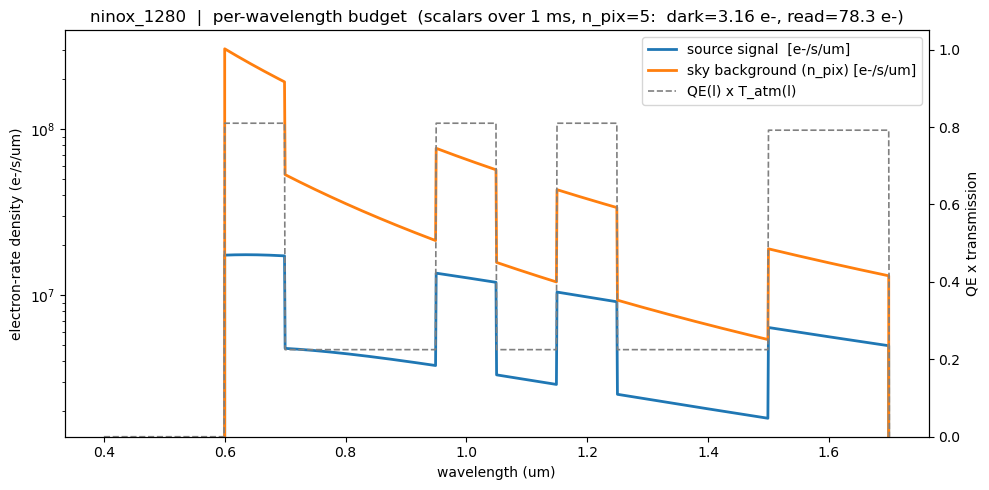

In [11]:
qe_a, _ = qe_of(ACTIVE_DETECTOR, GRID_UM)
npar_a  = noise_params(ACTIVE_DETECTOR)
pitch_a = npar_a["pitch_um"] or PITCH_TOY_PLACEHOLDER_UM
omega_a = (pitch_a*1e-6/FOCAL_LENGTH_M)**2

S_lam_density   = E_tgt_m * A_TEL * TAU_OPTICS * T_atm * lam_m/(H*C) * qe_a * 1e-6            # e-/s/um (source)
sky_lam_density = sky_radiance_m(GRID_UM) * A_TEL*omega_a*TAU_OPTICS*T_atm * lam_m/(H*C) * qe_a * N_PIX_PSF * 1e-6  # e-/s/um (sky, n_pix)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(GRID_UM, S_lam_density,  color="tab:blue",  lw=2, label="source signal  [e-/s/um]")
ax.plot(GRID_UM, sky_lam_density, color="tab:orange", lw=2, label="sky background (n_pix) [e-/s/um]")
ax.set_yscale("log"); ax.set_xlabel("wavelength (um)"); ax.set_ylabel("electron-rate density (e-/s/um)")
ax2 = ax.twinx()
ax2.plot(GRID_UM, qe_a*T_atm, color="0.5", ls="--", lw=1.2, label="QE(l) x T_atm(l)")
ax2.set_ylabel("QE x transmission"); ax2.set_ylim(0, 1.05)
ax.set_title("%s  |  per-wavelength budget  (scalars over %d ms, n_pix=%d:  dark=%.2f e-, read=%.1f e-)"
             % (ACTIVE_DETECTOR, T_INT_S*1e3, N_PIX_PSF, R["terms"]["dark"], R["terms"]["read"]))
h1,l1 = ax.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, loc="upper right"); plt.tight_layout(); plt.show()

## 10. Comparison table — all three detectors, identical scenario

Loop every detector through the identical fixed scenario and tabulate integrated SNR, source photon
(electron) rate, the dominant noise term, and each budget component. **toy_model's row is flagged: its
QE is a non-physical placeholder, so its SNR is not comparable.**

In [12]:
rows = []
for k in ("ninox_1280", "scion_visgaas", "toy_model"):
    r = run_detector(k)
    rows.append({
        "detector": k,
        "SNR_int": round(r["snr"], 1),
        "signal_e_per_s": "%.2e" % r["S_rate"],
        "dominant_noise": r["dominant"],
        "shot_e": round(r["terms"]["shot"], 1),
        "sky_e": round(r["terms"]["sky"], 1),
        "read_e": round(r["terms"]["read"], 1) if not r["bound"] else "<%.1f" % r["terms"]["read"],
        "dark_e": round(r["terms"]["dark"], 2),
        "saturated": r["saturated"],
        "flag": ("QE ASSUMED - NOT PHYSICAL" if k == "toy_model"
                 else ("noise = UPPER BOUNDS" if r["bound"] else "")),
    })
table = pd.DataFrame(rows).set_index("detector")
print("Fixed scenario: 1U CubeSat @ 500 km, t=%.0f ms, daytime sky (SKY_VIS_REF=%.0f).  All values inherit the placeholders."
      % (T_INT_S*1e3, SKY_VIS_REF))
table

Fixed scenario: 1U CubeSat @ 500 km, t=1 ms, daytime sky (SKY_VIS_REF=20).  All values inherit the placeholders.


,SNR_int,signal_e_per_s,dominant_noise,shot_e,sky_e,read_e,dark_e,saturated,flag
detector,,,,,,,,,
ninox_1280,28.2,7.05e+06,sky,84.0,222.4,78.3,3.16,False,
scion_visgaas,23.2,9.50e+06,sky,97.5,392.5,<67.1,0.27,False,noise = UPPER BOUNDS
toy_model,25.4,1.12e+07,sky,105.7,425.8,33.5,0.10,False,QE ASSUMED - NOT PHYSICAL


**Reading the table (at the daytime sky level used here):** the budget is **sky-dominated**, so the
detector that admits the *least* sky wins. Ninox (0.6–1.7 µm, no visible) collects less sky than SCION
(0.4–1.7 µm, includes the bright visible), so despite SCION's wider signal band and lower read noise,
**Ninox posts the higher SNR** — the SWIR daytime advantage the paper is built around. toy_model's number
is highest only because of its flat QE=1.0 placeholder and is **not physically comparable**.

## 11. Sensitivity: the ranking flips between night and day

The prompt's premise — atmosphere absolute level is not load-bearing, only consistency matters — holds
**only when sky is sub-dominant**. Here we re-run at a low (night) sky level and the daytime level to show
the ranking is regime-dependent. This is a finding, not a bug: at realistic daytime sky the atmosphere is
the dominant differentiator, so "detector-only isolation" is only strictly true in the signal/read-limited
(night) regime.

In [13]:
for label, sky in [("NIGHT (sky ~ 0)", 1e-3), ("DAY (placeholder)", SKY_VIS_REF)]:
    line = "  ".join("%s SNR=%5.1f (%s-dom)" % (k.split('_')[0], run_detector(k, sky_vis=sky)["snr"],
                                                run_detector(k, sky_vis=sky)["dominant"])
                     for k in ("ninox_1280","scion_visgaas","toy_model"))
    print("%-18s : %s" % (label, line))
print("\nNight: signal/read-limited -> SCION's wider band + lower read noise wins.")
print("Day  : sky-limited        -> NINOX's SWIR-only band (less visible sky) wins. (toy = placeholder QE)")

NIGHT (sky ~ 0)    : ninox SNR= 61.4 (shot-dom)  scion SNR= 80.3 (shot-dom)  toy SNR=100.8 (shot-dom)
DAY (placeholder)  : ninox SNR= 28.2 (sky-dom)  scion SNR= 23.2 (sky-dom)  toy SNR= 25.4 (sky-dom)

Night: signal/read-limited -> SCION's wider band + lower read noise wins.
Day  : sky-limited        -> NINOX's SWIR-only band (less visible sky) wins. (toy = placeholder QE)


## 12. Assumptions, placeholders, and the Ninox discrepancy (summary)

**Every non-paper value introduced, in one place:**

| quantity | value used | status |
|---|---|---|
| Solar spectrum | 5778 K blackbody @ 1361 W/m² | **substitute** for the paper's WHI curve |
| Target geometry (1U LEO) | area 0.01/0.06 m², albedo 0.20/0.25, 500 km, phase 0.5, Earthshine frac 0.30 | **placeholders**, not from paper, not reverse-engineered |
| BRDF functional forms | Lambertian diffuse + gated specular lobe + Earthshine | **parametrization** of eqs 3–7, not verbatim |
| Specular glint | `specular_alignment = 0` (off) | conservative sustained case |
| Atmosphere transmission | flat windows 1.0/1.2/1.6 µm + visible, 0.25 floor | **illustrative**, no line structure |
| Sky radiance | λ⁻⁴ Rayleigh; Mie = 0, airglow = 0 | **omissions flagged**; achieved SWIR/vis ~11× vs paper's ~20× |
| Daytime sky level | `SKY_VIS_REF = 20` W/m²/sr/µm | **placeholder** absolute level (drives §11) |
| Mirror throughput | 0.98³ ≈ 0.94 | **assumed** (paper gives no coefficient) |
| Aperture obscuration | none (unobstructed) | **assumed** |
| Integration time / n_pix | 1 ms / 5 px | **placeholders**, fixed across detectors |
| QE(λ) for ninox/scion | flat `qe_peak` within `spectral_range` | **assumed** (qe_curve null for all) |
| QE(λ) for toy_model | `TOY_MODEL_QE_PLACEHOLDER = 1.0` | **NON-PHYSICAL** placeholder |
| toy_model pixel pitch | 10 µm | **placeholder** (config has none; sky solid-angle only) |

**The Ninox ADU-vs-electron discrepancy (open question).** `configs/detector_configs.json` carries two
disjoint Ninox noise sets:

- **paper (ADU/cts):** read 224.1 ADU (high gain), dark 205.7 cts/s — gain unknown.
- **datasheet (electrons, −15 °C):** read 35 e− (hg typical), dark 2000 e−/s (typical).

These **cannot be reconciled under any single plausible gain**: a gain that maps 224.1 ADU → 35 e−
(≈0.156 e−/ADU) maps 205.7 cts/s → ~32 e−/s dark — roughly **50× below** the datasheet's 2000 e−/s. Since
eq 10 is defined in photo-electrons, this notebook uses the **datasheet electron values** and does **not**
invent a gain to force a fit. The discrepancy is left open and recorded in
`docs/recon/0002-detector-comparison-benchmark.md`.

---
*This notebook is a parametric benchmark, not a paper reproduction. Treat the absolute SNR numbers as
scenario-dependent to within the placeholders above; the load-bearing content is the **relative** detector
behaviour under an identical scenario, with the §11 caveat that at daytime sky levels the atmosphere,
not the detector, dominates.*